# Campaign Finance as a Random Walk of Money

The following code runs the analyses found in the paper. It uses `igraph`. 

## 1. Build graphs
This builds 12 graphs for the cycles in 2000-2022. Each one is a snapshot of their "final state", i.e. edge existences and weights are cumulative from the whole 2-year period. 

In [ ]:
# Misc
import numpy as np
import random
import sys
import pandas as pd
from collections import defaultdict

# Graph analysis tools
import igraph as ig
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "graphs"))
from build_graph import build_graph
from lpa import lpa_run, lpa_build_matrix, lpa_idea_dist, lpa_preprocess

# Plot settings
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
plt.rcParams["text.usetex"] = False
_SERIF_RC = {
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["cmr10", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
}

In [2]:
graphs = []
years = [2000, 2002, 2004, 2006, 2008, 2010, 2012,
         2014, 2016, 2018, 2020, 2022]

for year in years: 
    g = build_graph(year)
    n0 = g.vcount()
    wccs = g.connected_components(mode="weak")
    top10_wcc = list(reversed(sorted([len(wcc) for wcc in wccs])))[0:10]
    num_iso = len([v for v in g.vs if g.degree(v, mode="ALL") == 0])
    # g_giant = g.connected_components(mode="weak").giant()
    print(f"{year}: {g.vcount()} nodes, {g.ecount()} edges, {num_iso} isolates | {len(wccs)} WCCs | Top 10 WCC sizes:", top10_wcc)
    graphs.append(g)

2000: 5666 nodes, 136889 edges, 0 isolates | 25 WCCs | Top 10 WCC sizes: [5609, 6, 4, 4, 3, 2, 2, 2, 2, 2]
2002: 5713 nodes, 133845 edges, 0 isolates | 19 WCCs | Top 10 WCC sizes: [5665, 12, 3, 3, 2, 2, 2, 2, 2, 2]
2004: 5853 nodes, 141950 edges, 0 isolates | 20 WCCs | Top 10 WCC sizes: [5803, 13, 3, 2, 2, 2, 2, 2, 2, 2]
2006: 6150 nodes, 156037 edges, 0 isolates | 20 WCCs | Top 10 WCC sizes: [6107, 6, 3, 2, 2, 2, 2, 2, 2, 2]
2008: 6303 nodes, 160377 edges, 0 isolates | 28 WCCs | Top 10 WCC sizes: [6224, 17, 6, 4, 3, 3, 3, 3, 2, 2]
2010: 6824 nodes, 169290 edges, 0 isolates | 29 WCCs | Top 10 WCC sizes: [6767, 3, 2, 2, 2, 2, 2, 2, 2, 2]
2012: 7058 nodes, 175143 edges, 0 isolates | 44 WCCs | Top 10 WCC sizes: [6947, 11, 9, 6, 5, 3, 3, 2, 2, 2]
2014: 6885 nodes, 176349 edges, 0 isolates | 49 WCCs | Top 10 WCC sizes: [6763, 13, 5, 4, 4, 3, 3, 3, 3, 3]
2016: 6933 nodes, 175715 edges, 0 isolates | 47 WCCs | Top 10 WCC sizes: [6830, 5, 4, 3, 3, 3, 3, 3, 3, 2]
2018: 7992 nodes, 193781 edges, 

### 1.1 Restrict to Absorbing Markov Chain
Next, we prune the 12 graphs to be valid absorbing Markov chains. 

In [3]:
def restrict(g):
    """
    Prunes the graph `g` to the absorbing chain, i.e. 
    it restricts `g` to those nodes which are reachable by 
    the candidate (sink) nodes.  
    """

    # Absorbing states are DEM/REP candidates
    cand = [v.index for v in g.vs if v["party"] in ("DEM", "REP")]

    # Reverse edges 
    g_rev = g.copy()
    g_rev.reverse_edges()           

    # Create phantom source `s` that leads to every absorbing state                   
    s = g_rev.add_vertex().index                        
    g_rev.add_edges([(s, c) for c in cand]) 

    # Isolate nodes that are reachable via the reverse graph, 
    # i.e. those that reach the absorbing states         
    reachable_nodes = sorted(set(g_rev.subcomponent(s, mode="out")) - {s})

    # Induced subgraph with original (!) directions
    return g.induced_subgraph(reachable_nodes)                

absorbing_graphs = []

for year, g in zip(years, graphs):
    absorbing_graph = restrict(g)

    # Sanity check: Every sink in the restricted graph
    # should be a DEM/REP candidate. 
    bad_sinks = sum(1 for v in absorbing_graph.vs if v.outdegree() == 0 
                    and v["party"] not in ("DEM", "REP"))
    absorbing_graphs.append(absorbing_graph)

    print(f"{year}: {g.vcount()}->{absorbing_graph.vcount()} nodes "
          f"({round((g.vcount() - absorbing_graph.vcount())/g.vcount()*100)}% pruned), "
          f"{g.ecount()}->{absorbing_graph.ecount()} edges | Non-DEM/REP-candidate sinks left: {bad_sinks}")


2000: 5666->4327 nodes (24% pruned), 136889->106073 edges | Non-DEM/REP-candidate sinks left: 0
2002: 5713->4528 nodes (21% pruned), 133845->107342 edges | Non-DEM/REP-candidate sinks left: 0
2004: 5853->4627 nodes (21% pruned), 141950->118863 edges | Non-DEM/REP-candidate sinks left: 0
2006: 6150->4939 nodes (20% pruned), 156037->134405 edges | Non-DEM/REP-candidate sinks left: 0
2008: 6303->5028 nodes (20% pruned), 160377->137597 edges | Non-DEM/REP-candidate sinks left: 0
2010: 6824->5329 nodes (22% pruned), 169290->144752 edges | Non-DEM/REP-candidate sinks left: 0
2012: 7058->5439 nodes (23% pruned), 175143->146644 edges | Non-DEM/REP-candidate sinks left: 0
2014: 6885->5436 nodes (21% pruned), 176349->156269 edges | Non-DEM/REP-candidate sinks left: 0
2016: 6933->5290 nodes (24% pruned), 175715->148962 edges | Non-DEM/REP-candidate sinks left: 0
2018: 7992->5845 nodes (27% pruned), 193781->164548 edges | Non-DEM/REP-candidate sinks left: 0
2020: 8710->6297 nodes (28% pruned), 187

Below, we visualize the share of edge types per cycle. 

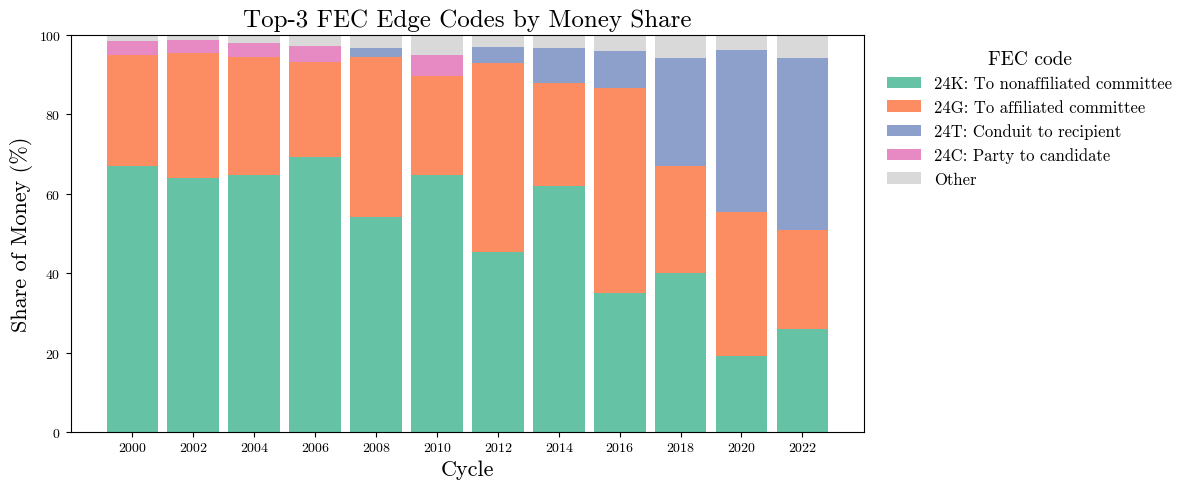

In [4]:
# amount-share per edge code, per cycle, and each cycle's top-3 codes
shares_by_year = []
for g in absorbing_graphs:
    amt = defaultdict(float)
    for t, a in zip(g.es["type"], g.es["amount"]): amt[t] += a
    tot = sum(amt.values())
    shares_by_year.append({k: v / tot for k, v in amt.items()})
top3_by_year = [sorted(s, key=s.get, reverse=True)[:3] for s in shares_by_year]

# Manual legend labels
code_labels = {
    "24K": "To nonaffiliated committee",
    "24G": "To affiliated committee",
    "24T": "Conduit to recipient",
    "24C": "Party to candidate",
    "Other": ""
}

# persistent color per code (union of all cycles' top-3), stacked in a fixed order
codes = sorted({c for t in top3_by_year for c in t},
               key=lambda c: -max(s.get(c, 0) for s in shares_by_year))
cmap = plt.get_cmap("Set2")
color = {c: cmap(i % 10) for i, c in enumerate(codes)}
color["Other"] = "0.85"

x = np.arange(len(years))
with plt.rc_context(_SERIF_RC):
    fig, ax = plt.subplots(figsize=(12, 5))
    bottom = np.zeros(len(years))
    for c in codes:
        seg = np.array([100 * shares_by_year[t].get(c, 0.0) if c in top3_by_year[t] else 0.0
                        for t in range(len(years))])
        ax.bar(x, seg, bottom=bottom, color=color[c], width=0.85, label=f"{c}: {code_labels.get(c, c)}")
        bottom += seg
    ax.bar(x, 100 - bottom, bottom=bottom, color=color["Other"], width=0.85, label="Other")
    ax.set_xticks(x); ax.set_xticklabels(years); ax.set_ylim(0, 100)
    ax.set_xlabel("Cycle", fontsize=16); ax.set_ylabel("Share of Money (%)", fontsize=16)
    ax.set_title("Top-3 FEC Edge Codes by Money Share", fontsize=18)
    ax.legend(title="FEC code", title_fontsize=14, loc="upper left",
              bbox_to_anchor=(1.01, 1.0), fontsize=12, frameon=False)
    fig.tight_layout(); plt.show()

## 2. Label Propagation

Run label propagation for each graph, collecting scores, labels, and their respective Markov $\mathbf{B}$ and $\mathbf{N}$ matrices. It also exports the labeled data as CSVs for use in visualization software. 

In [5]:
# For each cycle, collect the following information
sD_list, sR_list, labels_list = [], [], []    # (sD, sR) scores, and binarized labels
ids_U_list, ids_L_list = [], []               # FEC IDs of unlabeled and labeled nodes
N_list, B_list = [], []                       # B (Markov kernel) and N (absorption time) matrices

for t, year in enumerate(years): 

    # Run label propagation
    g = absorbing_graphs[t]
    sD, sR, labels, ids_U, ids_L, N, H = lpa_run(g)

    # Add the scores and binarized labels as node attributes
    g.vs["sD"] = [sD.get(v["name"]) for v in g.vs] 
    g.vs["sR"] = [sR.get(v["name"]) for v in g.vs] 
    g.vs["label"] = ["DEM" if sD.get(v["name"]) > sR.get(v["name"])
                           else "REP" if sR.get(v["name"]) > sD.get(v["name"])
                            else "UNK" for v in g.vs]
    
    # Collect data
    sD_list.append(sD); sR_list.append(sR); labels_list.append(labels)
    ids_U_list.append(ids_U); ids_L_list.append(ids_L)
    B_list.append(H); N_list.append(N)
    l = len(ids_L); u = len(ids_U)
    print(f"{year} done | {l} labeled nodes, {u} unlabeled nodes | {round(l/(l+u), 3)*100}% labeled")

    # For export purposes: Add is_cand feature
    # (I used Cosmograph, which refused Boolean coloring, so it is a string value)
    cand_names = set(ids_L)
    g.vs["is_cand"] = ["CAND" if v["name"] in cand_names else "NOT_CAND" for v in g.vs]
    g.vs["lean"] = [ sD - sR if sD is not None and sR is not None else None
        for sD, sR in zip(g.vs["sD"], g.vs["sR"])]
    cols = ["name", "label", "is_cand", "state", "total_out", "lean", "sD", "sR"]
    vertices = pd.DataFrame([{col: v[col] for col in cols} for v in g.vs])
    vertices.to_csv(Path("../graphs") / f"{year}_vertices_labeled.csv", index=False)

# Bookkeeping for computation:
# Map FEC IDs to iGraph indices
# for use in indexing the H-matrix. 
name2idx_list = []
for yr in range(len(years)): 
    d = {v["name"]: v.index for v in absorbing_graphs[yr].vs}
    name2idx_list.append(d)

2000 done | 358 labeled nodes, 3969 unlabeled nodes | 8.3% labeled
2002 done | 401 labeled nodes, 4127 unlabeled nodes | 8.9% labeled
2004 done | 303 labeled nodes, 4324 unlabeled nodes | 6.5% labeled
2006 done | 379 labeled nodes, 4560 unlabeled nodes | 7.7% labeled
2008 done | 303 labeled nodes, 4725 unlabeled nodes | 6.0% labeled
2010 done | 375 labeled nodes, 4954 unlabeled nodes | 7.000000000000001% labeled
2012 done | 258 labeled nodes, 5181 unlabeled nodes | 4.7% labeled
2014 done | 252 labeled nodes, 5184 unlabeled nodes | 4.6% labeled
2016 done | 158 labeled nodes, 5132 unlabeled nodes | 3.0% labeled
2018 done | 276 labeled nodes, 5569 unlabeled nodes | 4.7% labeled
2020 done | 300 labeled nodes, 5997 unlabeled nodes | 4.8% labeled
2022 done | 253 labeled nodes, 5945 unlabeled nodes | 4.1000000000000005% labeled


Here we visualize the number of candidates per cycle. 

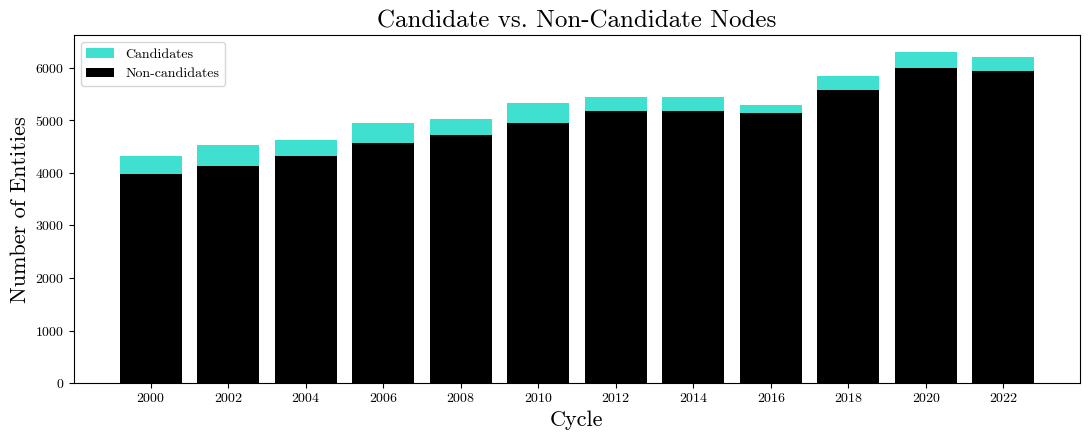

In [58]:
dem_ct, rep_ct, noncand_ct = [], [], []
for g in absorbing_graphs:
    dem = sum(1 for v in g.vs if v["party"] == "DEM")
    rep = sum(1 for v in g.vs if v["party"] == "REP")
    dem_ct.append(dem); rep_ct.append(rep); noncand_ct.append(g.vcount() - dem - rep)
dem_ct = np.array(dem_ct); rep_ct = np.array(rep_ct); noncand_ct = np.array(noncand_ct)
x = np.arange(len(years))
with plt.rc_context(_SERIF_RC):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x, dem_ct, bottom=noncand_ct,               color="turquoise", label="Candidates")
    ax.bar(x, rep_ct, bottom=noncand_ct + dem_ct,      color="turquoise")
    ax.bar(x, noncand_ct, color="black",       label="Non-candidates")
    ax.set_xticks(x); ax.set_xticklabels(years)
    ax.set_xlabel("Cycle", fontsize=16); ax.set_ylabel("Number of Entities", fontsize=16)
    ax.set_title("Candidate vs. Non-Candidate Nodes", fontsize=18)
    ax.legend(loc="upper left")
    fig.tight_layout(); plt.show()

## 3. Analysis

### 3.1 Null Models

`run_null_simulations.py` runs the null-model simulations. Here the results are plotted. 

In [ ]:
_C_PERM, _C_DIR = "lightseagreen", "darkorange"

POL  = pd.read_csv("sims_polarization.csv")   # per (year, bin_center): sR-sD density
ENT  = pd.read_csv("sims_entropy.csv")         # per year: ent_diff (R-D)
LEAK = pd.read_csv("sims_leakage.csv")         # per year: leak_diff (R-D)
_SIM_YEARS = sorted(ENT["year"].tolist())

def plot_null_timeseries(df, ylabel, title):
    """Year-axis plot of a scalar-stat frame (ENT or LEAK):
    Real graph, unweighted graph, and each null's mean and translucent 95% CI band."""
    yy = np.array(_SIM_YEARS); si = df.set_index("year")
    real = si.loc[_SIM_YEARS, "real"].to_numpy()
    unw  = si.loc[_SIM_YEARS, "unweighted"].to_numpy()
    with plt.rc_context(_SERIF_RC):
        fig, ax = plt.subplots(figsize=(9, 4.3))
        # Dotted vertical year lines: black on presidential cycles (year % 4 == 0), gray otherwise.
        for yv in _SIM_YEARS:
            ax.axvline(yv, ls=":", lw=1.0, zorder=0, color="black" if yv % 4 == 0 else "0.7")
        for name, c in (("permuted", _C_PERM), ("dirichlet", _C_DIR)):
            lo   = si.loc[_SIM_YEARS, f"{name}_lo"].to_numpy()
            hi   = si.loc[_SIM_YEARS, f"{name}_hi"].to_numpy()
            mean = si.loc[_SIM_YEARS, f"{name}_mean"].to_numpy()
            ax.fill_between(yy, lo, hi, color=c, alpha=0.22, lw=0, label=f"{name.capitalize()} null (mean, 95% CI)")
            ax.plot(yy, mean, color=c, lw=1.0)
        ax.plot(yy, real, color="black", marker=".", ms=8, lw=1.4, label="Real graph")
        ax.plot(yy, unw,  color="0.45", ls="--", marker=".", ms=7, lw=1.1, label="Unweighted graph")
        ax.axhline(0, color="grey", lw=0.6, zorder=0)
        ax.set_xlabel("Cycle", fontsize=14); ax.set_ylabel(ylabel, fontsize=14); ax.set_xticks(_SIM_YEARS)
        ax.set_title(title, fontsize=18); ax.legend(fontsize=11, ncol=2)
        fig.tight_layout(); plt.show()

### 3.2 Polarization

First, we plot the density of real scores obtained from label propagation. Specifically, the *lean* $s_R - s_D \in [-1, 1]$, which is $-1$ for strongly Democratic nodes and $+1$ for strongly Republican nodes. 

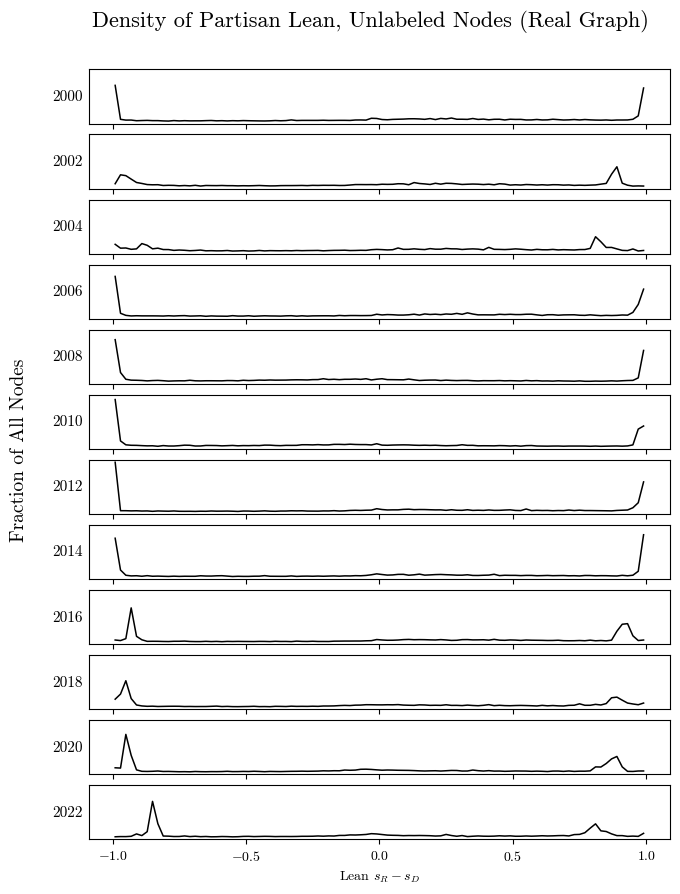

In [8]:
with plt.rc_context(_SERIF_RC):
    fig,axes=plt.subplots(len(_SIM_YEARS),1,figsize=(7.5,10.0),sharex=True,sharey=True)
    for ax,y in zip(axes,_SIM_YEARS):
        d=POL[POL["year"]==y]
        ax.plot(d["bin_center"],d["real"],color="black",lw=1.1)
        ax.set_ylabel(y,rotation=0,ha="right",va="center",fontsize=11); ax.set_yticks([]); ax.margins(y=0.05)
    axes[-1].set_xlabel(r"Lean $s_R - s_D$"); axes[-1].set_xticks([-1,-0.5,0,0.5,1])
    leg=[Line2D([0],[0],color="black",lw=1.1,label="Real graph")]
    fig.suptitle(r"Density of Partisan Lean, Unlabeled Nodes (Real Graph)",y=0.94,fontsize=16)
    fig.supylabel("Fraction of All Nodes", fontsize=14); plt.show()

Next, we plot the same data, but with null model results. 

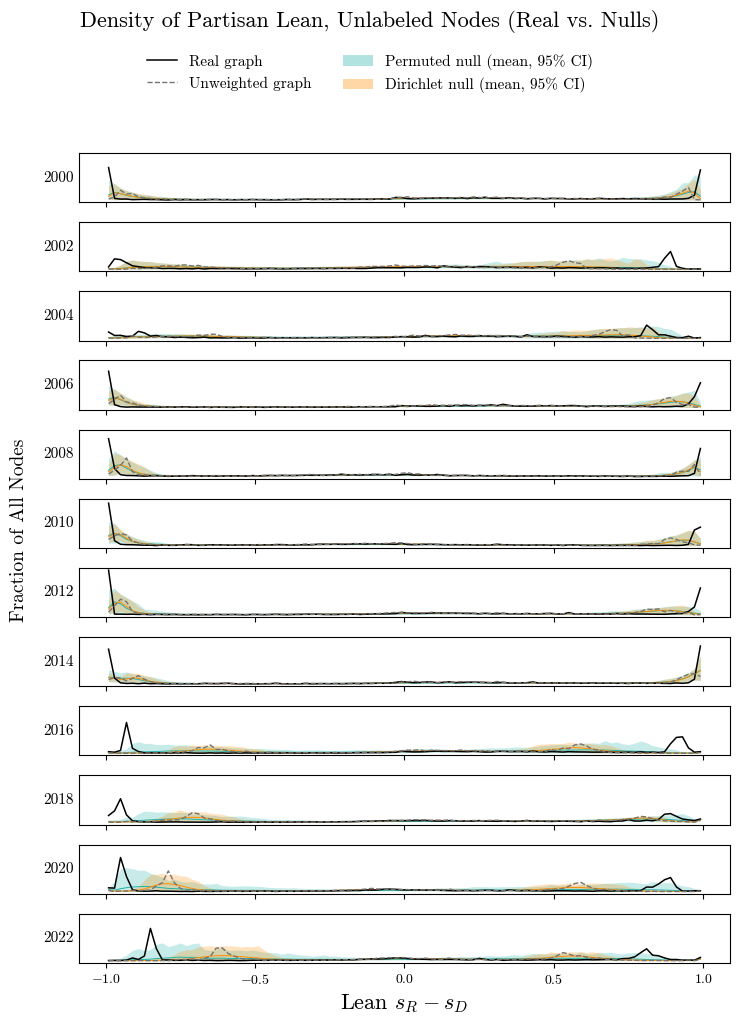

In [9]:
with plt.rc_context(_SERIF_RC):
    fig,axes=plt.subplots(len(_SIM_YEARS),1,figsize=(7.5,10.0),sharex=True,sharey=True)
    for ax,y in zip(axes,_SIM_YEARS):
        d=POL[POL["year"]==y]
        for name,c in (("permuted",_C_PERM),("dirichlet",_C_DIR)):
            ax.fill_between(d["bin_center"],d[f"{name}_lo"],d[f"{name}_hi"],color=c,alpha=0.25,lw=0)
            ax.plot(d["bin_center"],d[f"{name}_mean"],color=c,lw=0.7)
        ax.plot(d["bin_center"],d["real"],color="black",lw=1.1)
        ax.plot(d["bin_center"],d["unweighted"],color="0.45",lw=1.0,ls="--")
        ax.set_ylabel(y,rotation=0,ha="right",va="center",fontsize=11); ax.set_yticks([]); ax.margins(y=0.05)
    axes[-1].set_xlabel(r"Lean $s_R - s_D$", fontsize=16); axes[-1].set_xticks([-1,-0.5,0,0.5,1])
    leg=[Line2D([0],[0],color="black",lw=1.1,label="Real graph"),
         Line2D([0],[0],color="0.45",lw=1.0,ls="--",label="Unweighted graph"),
         Patch(facecolor=_C_PERM,alpha=0.35,label="Permuted null (mean, 95% CI)"),
         Patch(facecolor=_C_DIR,alpha=0.35,label="Dirichlet null (mean, 95% CI)")]
    fig.legend(handles=leg,loc="upper center",ncol=2,fontsize=11,frameon=False,bbox_to_anchor=(0.5,0.99))
    fig.suptitle("Density of Partisan Lean, Unlabeled Nodes (Real vs. Nulls)",y=1.02,fontsize=16)
    fig.supylabel("Fraction of All Nodes", fontsize=14); fig.tight_layout(rect=[0,0,1,0.93]); plt.show()

### 3.3 Absorption Probabilities

#### 3.3.1 In-Party Dynamics

In-party normalized absorption entropy (normalized by the number of candidates, for better cross-cycle analysis), aggregate over a party by a weighted average over out-strengths. 

In [37]:
from scipy.sparse import csr_matrix

def inparty_absorption_entropy(g, H, ids_U, ids_L, labels, name2idx=None):
    """
    (entropy_D, entropy_R): out-strength-weighted average of the normalized
    within-party absorption entropy, per party. Fully vectorized over H's rows;
    numerically identical to the original loop. Takes the H from lpa_run -- does
    no solve -- so it is cheap enough to run over many null models.
    """
    H = H.tocsr() if hasattr(H, "tocsr") else csr_matrix(H)
    if name2idx is None:
        name2idx = {v["name"]: v.index for v in g.vs}

    # Split H's absorbing columns by the candidate's known party.
    col_party = np.array([g.vs[name2idx[cid]]["party"] for cid in ids_L])
    dem_cols = np.flatnonzero(col_party == "DEM")
    rep_cols = np.flatnonzero(col_party == "REP")

    # Row LPA labels + out-strengths (one vectorized strength call, not one per node).
    lab = np.array([labels[i] for i in ids_U])
    w = np.asarray(g.strength([name2idx[i] for i in ids_U],
                              mode="out", weights="amount"), dtype=float)

    def block_entropy(cols):
        """Per-row normalized entropy of the H[:, cols] block; 0 where undefined."""
        n_cand = len(cols)
        ent = np.zeros(H.shape[0])
        good = np.zeros(H.shape[0], dtype=bool)
        if n_cand < 2:                                # entropy undefined for < 2 candidates
            return ent, good
        B = H[:, cols]
        mass = np.asarray(B.sum(axis=1)).ravel()
        Blogb = B.copy()
        d = Blogb.data
        pos = d > 0                                   # exclude log() on 0-prob entries
        dlogd = np.zeros_like(d)
        dlogd[pos] = d[pos] * np.log(d[pos])          # 0*log 0 := 0
        Blogb.data = dlogd
        s = np.asarray(Blogb.sum(axis=1)).ravel()
        good = mass > 0
        ent[good] = (np.log(mass[good]) - s[good] / mass[good]) / np.log(n_cand)
        return ent, good

    ent_d, good_d = block_entropy(dem_cols)
    ent_r, good_r = block_entropy(rep_cols)
    mD = (lab == "DEM") & good_d
    mR = (lab == "REP") & good_r
    entropy_D = float(np.dot(ent_d[mD], w[mD]))
    entropy_R = float(np.dot(ent_r[mR], w[mR]))

    # Denominators: total out-strength of all DEM/REP-labeled vertices (unchanged).
    D_strength = sum(g.strength([v.index for v in g.vs if v["label"] == "DEM"],
                                mode="out", weights="amount"))
    R_strength = sum(g.strength([v.index for v in g.vs if v["label"] == "REP"],
                                mode="out", weights="amount"))
    entropy_D = entropy_D / D_strength if D_strength else np.nan
    entropy_R = entropy_R / R_strength if R_strength else np.nan
    return entropy_D, entropy_R


entropies_D, entropies_R = [], []
for yr, year in enumerate(years):
    eD, eR = inparty_absorption_entropy(
        absorbing_graphs[yr], B_list[yr], ids_U_list[yr], ids_L_list[yr],
        labels_list[yr], name2idx_list[yr])
    entropies_D.append(eD)
    entropies_R.append(eR)
    print(f"Cross-party leakage probability {year}: D={np.round(eD*100)}%, R={np.round(eR*100)}%")

Cross-party leakage probability 2000: D=52.0%, R=77.0%
Cross-party leakage probability 2002: D=64.0%, R=80.0%
Cross-party leakage probability 2004: D=67.0%, R=69.0%
Cross-party leakage probability 2006: D=65.0%, R=74.0%
Cross-party leakage probability 2008: D=77.0%, R=71.0%
Cross-party leakage probability 2010: D=73.0%, R=78.0%
Cross-party leakage probability 2012: D=76.0%, R=69.0%
Cross-party leakage probability 2014: D=65.0%, R=71.0%
Cross-party leakage probability 2016: D=61.0%, R=75.0%
Cross-party leakage probability 2018: D=68.0%, R=80.0%
Cross-party leakage probability 2020: D=44.0%, R=68.0%
Cross-party leakage probability 2022: D=75.0%, R=80.0%


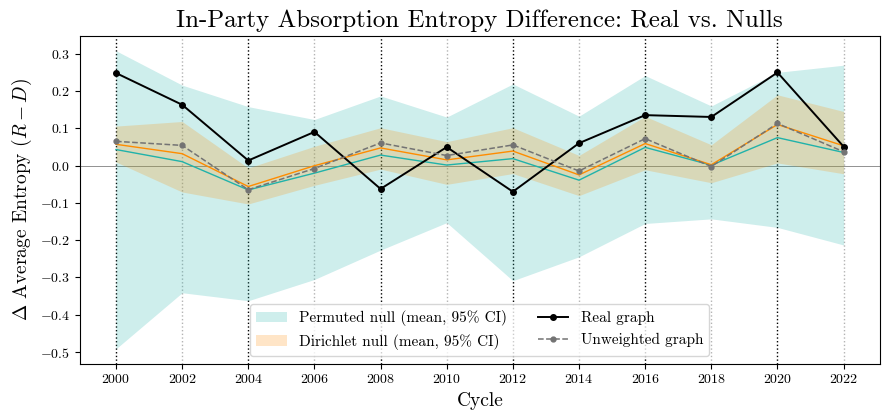

In [38]:
# Plot entropy results
plot_null_timeseries(ENT, r"$\Delta$ Average Entropy $(R-D)$",
                     "In-Party Absorption Entropy Difference: Real vs. Nulls")

#### 3.3.2 Cross-Party Dynamics

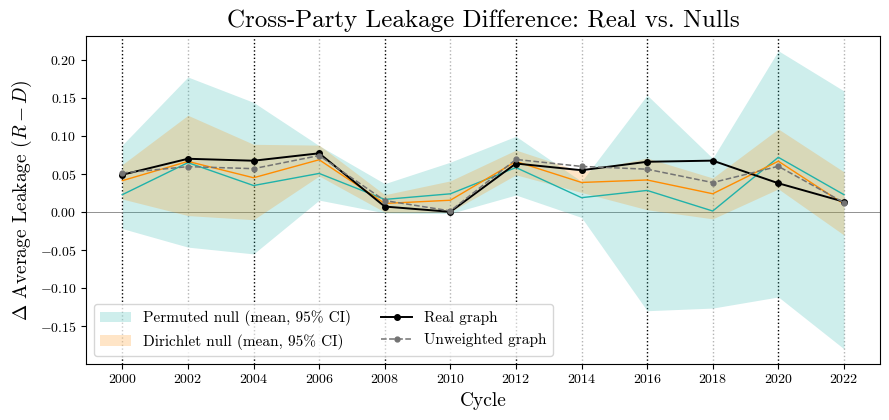

In [40]:
# Plot leakage results
plot_null_timeseries(LEAK, r"$\Delta$ Average Leakage $(R-D)$",
                     "Cross-Party Leakage Difference: Real vs. Nulls")

Who is leaking the money? Below we take the top 5 leakers by leakage probability from each cycle, so that we have 60 top leakers. We consider the money leaked as their leakage probability multiplied by their out-strength. This total leakage is separated by party, and we further visualize the organization types that they originate in. As we can see, they are overwhelmingly from corporations and trade organizations. 

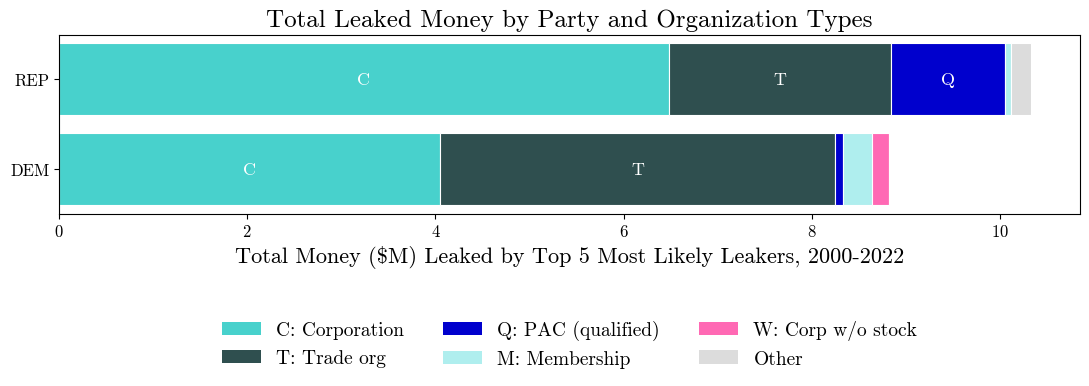

In [64]:
# Legend descriptions
_ORG  = {"C": "Corporation", "L": "Labor", "M": "Membership", "T": "Trade org",
         "V": "Cooperative", "W": "Corp w/o stock"}
_CMTE = {"N": "PAC (nonqual.)", "Q": "PAC (qualified)", "O": "Super PAC", "V": "Hybrid PAC",
         "W": "Hybrid PAC (nonq.)", "H": "House cmte", "S": "Senate cmte", "P": "Pres. cmte",
         "X": "Party (nonqual.)", "Y": "Party (qual.)", "Z": "Party nonfed.", "D": "Delegate",
         "I": "IE filer", "U": "Single-cand IE", "E": "Electioneering"}

def _node_cat(v):
    """Type category of a node: org_tp if it has a sponsoring org, else its cmte_tp."""
    ot = v["org_tp"]
    if isinstance(ot, str) and ot:
        return ("org", ot)
    ct = v["cmte_tp"]
    return ("cmte", ct if isinstance(ct, str) and ct else "?")

# Aggregate by party
_agg = {"REP": defaultdict(float), "DEM": defaultdict(float)}
for yr, year in enumerate(years):
    g = absorbing_graphs[yr]; name2idx = name2idx_list[yr]
    ids_U = ids_U_list[yr]; ids_L = ids_L_list[yr]; labels = labels_list[yr]
    H = B_list[yr]; H = H.tocsr() if hasattr(H, "tocsr") else csr_matrix(H)
    col_party = np.array([g.vs[name2idx[cid]]["party"] for cid in ids_L])
    h_D = np.asarray(H[:, np.flatnonzero(col_party == "DEM")].sum(axis=1)).ravel()
    h_R = np.asarray(H[:, np.flatnonzero(col_party == "REP")].sum(axis=1)).ravel()
    lab = np.array([labels[i] for i in ids_U])
    for party, cross in (("REP", h_D), ("DEM", h_R)):     # REP leaks to DEM via h_D, DEM via h_R
        rows = np.flatnonzero(lab == party)
        top = rows[np.argsort(cross[rows])[::-1][:5]]     # 5 most-likely leakers this cycle
        for k in top:
            v = g.vs[name2idx[ids_U[k]]]
            _agg[party][_node_cat(v)] += cross[k] * float(v["total_out"])   # leaked $

# Keep the five most common types by combined leaked money; lump the rest into "Other"
_tot = {p: sum(_agg[p].values()) for p in ("REP", "DEM")}
_types = sorted({c for p in ("REP", "DEM") for c in _agg[p]},
                key=lambda c: -(_agg["REP"].get(c, 0) + _agg["DEM"].get(c, 0)))[:5]
_OTHER = ("other", "Other")
_order = _types + [_OTHER]
_PALETTE = ["mediumturquoise", "darkslategrey", "mediumblue", "paleturquoise", "hotpink"]
_col = {c: _PALETTE[i] for i, c in enumerate(_types)}
_col[_OTHER] = "gainsboro"

# An organization type's leaked money
def _seg(party, c):                                      
    if c == _OTHER:
        return sum(m for cc, m in _agg[party].items() if cc not in _types)
    return _agg[party].get(c, 0.0)

# Legend label
def _leg(c):                                             
    if c == _OTHER:
        return "Other"
    return f"{c[1]}: {(_ORG if c[0] == 'org' else _CMTE).get(c[1], c[1])}"

with plt.rc_context(_SERIF_RC):
    fig, ax = plt.subplots(figsize=(11, 5))
    for party, yv in (("REP", 1), ("DEM", 0)):
        left = 0.0
        for c in _order:                                  # Same order for both bars
            val = _seg(party, c) / 1e6                    # Money in millions
            if val <= 0:
                continue
            ax.barh(yv, val, left=left, color=_col[c], edgecolor="white", lw=0.8)
            # Label segments that are >= 5% of the bar
            if val / (_tot[party] / 1e6) >= 0.05:         
                ax.text(left + val / 2, yv, "Oth" if c == _OTHER else c[1],
                        ha="center", va="center", fontsize=13, color="white")
            left += val
    ax.set_yticks([0, 1]); ax.set_yticklabels(["DEM", "REP"], fontsize=12)
    ax.tick_params(axis="x", labelsize=12)
    ax.set_xlabel("Total Money ($M) Leaked by Top 5 Most Likely Leakers, 2000-2022", fontsize=16)
    ax.set_title("Total Leaked Money by Party and Organization Types",
                 fontsize=18)
    ax.legend(handles=[Patch(facecolor=_col[c], label=_leg(c)) for c in _order],
              loc="upper center", bbox_to_anchor=(0.5, -0.5), ncol=3, fontsize=14, frameon=False)
    fig.tight_layout()
    plt.show()


### 3.4 Absorption Times

#### 3.4.1 Conditioned on Source

These are the weighted-average absorption times, restricted to *source* nodes for clearer semantics. The weighted average is by node out-strength relative to the party's total out-strength. These numbers are provided by $\mathbf{N1}$. 

In [42]:
absorption_times_D, absorption_times_R = [], []

for yr, year in enumerate(years):
    g        = absorbing_graphs[yr]
    name2idx = name2idx_list[yr]
    ids_U    = ids_U_list[yr]
    labels   = labels_list[yr]
    N        = N_list[yr]

    vidx = [name2idx[i] for i in ids_U]                 

    # Expected absorption time per transient node = row sum of N
    t = np.asarray(N.sum(axis=1)).ravel()

    # igraph check: Source transient nodes have in-degree 0
    is_src = np.array(g.indegree(vidx)) == 0

    lab = np.array([labels[i] for i in ids_U])
    w   = np.asarray(g.strength(vidx, mode="out", weights="amount"), dtype=float)

    def weighted_avg_time(party):
        # Out-strength-weighted mean over that party's source nodes: each node's weight
        # is its outgoing strength as a share of the party's total (source) out-strength,
        # i.e. weight_i = w_i / sum_{party sources} w.
        m = is_src & (lab == party)
        W = w[m].sum()
        return float(np.dot(t[m], w[m]) / W) if W > 0 else np.nan

    absorption_times_D.append(weighted_avg_time("DEM"))
    absorption_times_R.append(weighted_avg_time("REP"))
    print(f"{year}: {int((is_src&(lab=='DEM')).sum())} D sources, "
          f"{int((is_src&(lab=='REP')).sum())} R sources | "
          f"Out-strength-weighted avg absorption time: D={absorption_times_D[-1]:.2f}, R={absorption_times_R[-1]:.2f}")

2000: 861 D sources, 1580 R sources | Out-strength-weighted avg absorption time: D=22.68, R=13.61
2002: 873 D sources, 1585 R sources | Out-strength-weighted avg absorption time: D=14.58, R=23.59
2004: 833 D sources, 1628 R sources | Out-strength-weighted avg absorption time: D=9.41, R=14.12
2006: 839 D sources, 1779 R sources | Out-strength-weighted avg absorption time: D=5.93, R=7.35
2008: 1603 D sources, 1103 R sources | Out-strength-weighted avg absorption time: D=6.25, R=6.62
2010: 1694 D sources, 1137 R sources | Out-strength-weighted avg absorption time: D=7.07, R=6.02
2012: 1095 D sources, 1681 R sources | Out-strength-weighted avg absorption time: D=7.78, R=7.20
2014: 997 D sources, 1851 R sources | Out-strength-weighted avg absorption time: D=12.45, R=8.06
2016: 769 D sources, 1944 R sources | Out-strength-weighted avg absorption time: D=20.74, R=16.02
2018: 996 D sources, 1682 R sources | Out-strength-weighted avg absorption time: D=12.55, R=12.82
2020: 1214 D sources, 1541 

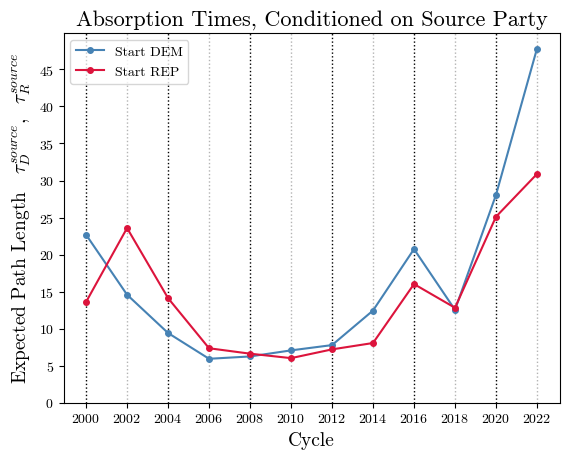

In [57]:
with plt.rc_context(_SERIF_RC):
    plt.figure()
    # Dotted vertical year lines: black on presidential cycles (year % 4 == 0), gray otherwise.
    for yv in years:
        plt.axvline(yv, ls=":", lw=1.0, zorder=0, color="black" if yv % 4 == 0 else "0.7")
    plt.plot(years, absorption_times_D, color="steelblue", marker=".", markersize=8, label="Start DEM")
    plt.plot(years, absorption_times_R, color="crimson", marker=".", markersize=8, label="Start REP")
    plt.xticks(years)
    plt.xlabel("Cycle", fontsize=14)
    plt.yticks(np.arange(0, 50, 5))
    plt.title("Absorption Times, Conditioned on Source Party", fontsize=16)
    plt.ylabel(r"Expected Path Length $~~\tau_D^{source},~~\tau_R^{source}$", fontsize=14)
    plt.legend(loc="upper left")
    plt.show()

#### 3.4.2 Conditioned on Sink

These are the weighted-average absorption times *conditioned on the absorbing sink's party* via a Doob $h$-transform. The weighted average is by node out-strength relative to the party's total out-strength.

In [51]:
from scipy.sparse import eye, diags, csc_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

def _conditioned_times(Q, h, eps=1e-12):
    """(I - D_h^{-1} Q D_h)^{-1} 1 on the support {h > eps}; NaN off-support."""
    t = np.full(Q.shape[0], np.nan)
    S = np.flatnonzero(h > eps)
    if S.size == 0:
        return t
    Qs   = Q[S][:, S]
    Qt   = diags(1.0 / h[S]) @ Qs @ diags(h[S])       # Doob h-transform on the support
    A    = (eye(S.size, format="csc") - Qt).tocsc()
    t[S] = spsolve(A, np.ones(S.size))
    return t

def _wavg(t, hp, is_src, w):
    """Money-weighted mean of t over source nodes, weighted by money ending in
    that party (out-strength * h_party) -- i.e. averaged over that-party-bound dollars."""
    m  = is_src & np.isfinite(t) & (hp > 0)
    ww = w[m] * hp[m]
    return float(np.dot(t[m], ww) / ww.sum()) if ww.sum() > 0 else np.nan

cond_times_D_list, cond_times_R_list = [], []   # per year, aligned to ids_U (NaN off-support)
cond_avg_D, cond_avg_R = [], []                 # money-weighted summary over source nodes

for yr, year in enumerate(years):
    g        = absorbing_graphs[yr]
    name2idx = name2idx_list[yr]
    ids_U    = ids_U_list[yr]
    ids_L    = ids_L_list[yr]

    # Transition submatrices aligned to (ids_L, ids_U) exactly as B_list was built.
    T_UL, T_UU = lpa_build_matrix(g, ids_L, ids_U)
    Q = T_UU.tocsr()

    # Harmonic functions = selective row sums of H over each party's columns
    H = B_list[yr]
    H = H.tocsr() if hasattr(H, "tocsr") else csr_matrix(H)
    col_party = np.array([g.vs[name2idx[cid]]["party"] for cid in ids_L])
    dem_cols  = np.flatnonzero(col_party == "DEM")
    rep_cols  = np.flatnonzero(col_party == "REP")
    h_D = np.asarray(H[:, dem_cols].sum(axis=1)).ravel()
    h_R = np.asarray(H[:, rep_cols].sum(axis=1)).ravel()

    # Conditioned absorption-time vectors
    t_D = _conditioned_times(Q, h_D)
    t_R = _conditioned_times(Q, h_R)
    cond_times_D_list.append(t_D)
    cond_times_R_list.append(t_R)

    # Summary
    vidx   = [name2idx[i] for i in ids_U]
    is_src = np.array(g.indegree(vidx)) == 0
    w      = np.asarray(g.strength(vidx, mode="out", weights="amount"), dtype=float)
    cond_avg_D.append(_wavg(t_D, h_D, is_src, w))
    cond_avg_R.append(_wavg(t_R, h_R, is_src, w))
    print(f"{year}:  E[time | ends DEM]={cond_avg_D[-1]:.2f}   E[time | ends REP]={cond_avg_R[-1]:.2f}")

2000:  E[time | ends DEM]=23.52   E[time | ends REP]=11.11
2002:  E[time | ends DEM]=10.74   E[time | ends REP]=29.65
2004:  E[time | ends DEM]=7.75   E[time | ends REP]=16.79
2006:  E[time | ends DEM]=5.34   E[time | ends REP]=8.27
2008:  E[time | ends DEM]=6.24   E[time | ends REP]=6.55
2010:  E[time | ends DEM]=7.58   E[time | ends REP]=5.60
2012:  E[time | ends DEM]=7.60   E[time | ends REP]=7.27
2014:  E[time | ends DEM]=10.43   E[time | ends REP]=8.70
2016:  E[time | ends DEM]=20.12   E[time | ends REP]=15.18
2018:  E[time | ends DEM]=11.86   E[time | ends REP]=13.58
2020:  E[time | ends DEM]=26.22   E[time | ends REP]=28.28
2022:  E[time | ends DEM]=56.21   E[time | ends REP]=22.29


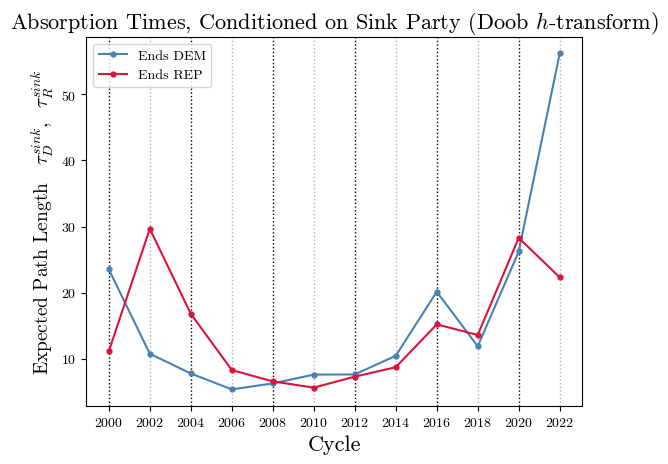

In [54]:
with plt.rc_context(_SERIF_RC):
    plt.figure()
    for yv in years:
        plt.axvline(yv, ls=":", lw=1.0, zorder=0, color="black" if yv % 4 == 0 else "0.7")
    plt.plot(np.array(years), cond_avg_D, color="steelblue", marker=".", markersize=7, label="Ends DEM")
    plt.plot(np.array(years), cond_avg_R, color="crimson",   marker=".", markersize=7, label="Ends REP")
    plt.title(r"Absorption Times, Conditioned on Sink Party (Doob $h$-transform)", fontsize=16)
    plt.xticks(years)
    plt.legend(loc="upper left")
    plt.xlabel("Cycle", fontsize=16)
    plt.ylabel(r"Expected Path Length $~~\tau_D^{sink},~~\tau_R^{sink}$", fontsize=14)
    plt.show()

#### 3.4.2 Cycles

Cycles increase random walk times by creating basins where money can recirculate.

The number of *independent cycles* in a directed graph $G = (V, E)$, which is called the **cyclomatic number**, is given by the following formula: 

Suppose there are $C$ weakly connected components, each with $V_i$ vertices and a spanning tree of size $|V_i| - 1$. Summing over the components, the spanning forest has $|V| - C$ edges. Since adding an edge anywhere to a forest completes a cycle, the number of cycles is given by the number of remaining edges $E - |V| + C$. 

In [65]:
cycles_list = []
scc_list = []

for t, year in enumerate(years): 

    g = absorbing_graphs[t]
    C = len(g.connected_components(mode="weak"))
    num_cycles = g.ecount() - g.vcount() + C
    nodes_in_cycles = sum(len(scc) for scc in g.connected_components(mode="strong")
                           if len(scc) > 1)
    cycles_list.append([num_cycles, nodes_in_cycles])

    sccs = g.connected_components(mode="strong")
    scc_list.append(sccs)
    
    print(f"{year}: Number of independent cycles: {num_cycles} | Nodes in nontrivial SCCs: {nodes_in_cycles:,}")

2000: Number of independent cycles: 101747 | Nodes in nontrivial SCCs: 1,163
2002: Number of independent cycles: 102815 | Nodes in nontrivial SCCs: 1,267
2004: Number of independent cycles: 114240 | Nodes in nontrivial SCCs: 1,564
2006: Number of independent cycles: 129468 | Nodes in nontrivial SCCs: 1,568
2008: Number of independent cycles: 132570 | Nodes in nontrivial SCCs: 1,675
2010: Number of independent cycles: 139424 | Nodes in nontrivial SCCs: 1,735
2012: Number of independent cycles: 141207 | Nodes in nontrivial SCCs: 1,960
2014: Number of independent cycles: 150836 | Nodes in nontrivial SCCs: 1,826
2016: Number of independent cycles: 143674 | Nodes in nontrivial SCCs: 1,986
2018: Number of independent cycles: 158711 | Nodes in nontrivial SCCs: 2,474
2020: Number of independent cycles: 158142 | Nodes in nontrivial SCCs: 2,809
2022: Number of independent cycles: 141695 | Nodes in nontrivial SCCs: 2,884


Below we visualize the partisan composition of the giant SCCs, as well as their overall size and share of the whole network across cycles. The top-3 actors within each cycle's giant SCC, ranked by total out-strength, is printed. 

2000: Giant SCC Size = 1133  (26.2% of network; DEM 470, REP 663)
    1. Out-strength 94,920,029 | NATIONAL REPUBLICAN CONGRESSIONAL COMMITTEE CONTRIBUTIONS [REP]
    2. Out-strength 49,745,893 | REPUBLICAN NATIONAL COMMITTEE - RNC [REP]
    3. Out-strength 39,066,183 | DNC SERVICES CORPORATION/DEMOCRATIC NATIONAL COMMITTEE [DEM]
2002: Giant SCC Size = 1202  (26.5% of network; DEM 581, REP 621)
    1. Out-strength 112,584,388 | NATIONAL REPUBLICAN CONGRESSIONAL COMMITTEE CONTRIBUTIONS [REP]
    2. Out-strength 41,202,243 | DEMOCRATIC CONGRESSIONAL CAMPAIGN COMMITTEE - CONTRIBUTIONS [DEM]
    3. Out-strength 37,670,781 | REPUBLICAN NATIONAL COMMITTEE [REP]
2004: Giant SCC Size = 1513  (32.7% of network; DEM 660, REP 853)
    1. Out-strength 49,169,087 | DNC SERVICES CORPORATION/DEMOCRATIC NATIONAL COMMITTEE [DEM]
    2. Out-strength 47,464,799 | JOHN KERRY FOR PRESIDENT, INC [DEM]
    3. Out-strength 45,081,134 | REPUBLICAN NATIONAL COMMITTEE [REP]
2006: Giant SCC Size = 1529  (31.0% of

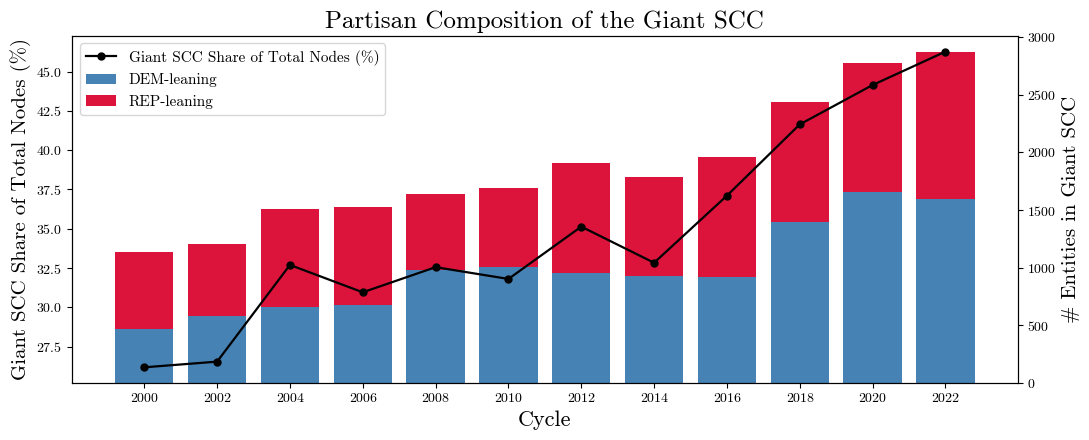

In [ ]:
dem_scc, rep_scc, oth_scc, scc_share = [], [], [], []
for yr, year in enumerate(years):
    giant = absorbing_graphs[yr].connected_components(mode="strong").giant()
    lbl = np.array(giant.vs["label"])
    d = int((lbl == "DEM").sum()); r = int((lbl == "REP").sum())
    dem_scc.append(d); rep_scc.append(r); oth_scc.append(giant.vcount() - d - r)
    scc_share.append(100 * giant.vcount() / absorbing_graphs[yr].vcount())     # % of the whole network

    tout = np.asarray(giant.vs["total_out"], dtype=float)
    top = np.argsort(tout)[::-1][:3]
    print(f"{year}: Giant SCC Size = {giant.vcount()}  ({scc_share[-1]:.1f}% of network; DEM {d}, REP {r})")
    for rank, i in enumerate(top, 1):
        v = giant.vs[i]
        print(f"    {rank}. Out-strength {tout[i]:,.0f} | {v['entity_name']} [{v['label']}]")

dem_scc = np.array(dem_scc); rep_scc = np.array(rep_scc); oth_scc = np.array(oth_scc)
x = np.arange(len(years))
with plt.rc_context(_SERIF_RC):
    fig, ax = plt.subplots(figsize=(11, 4.5))     # Left axis = Giant SCC share (%)
    ax2 = ax.twinx()                              # Right axis = Entity counts (bars)

    # Stacked bars on the right axis.
    ax2.bar(x, dem_scc, color="steelblue", label="DEM-leaning")
    ax2.bar(x, rep_scc, bottom=dem_scc, color="crimson", label="REP-leaning")
    if oth_scc.sum():                             # only if any node is unlabeled (UNK)
        ax2.bar(x, oth_scc, bottom=dem_scc + rep_scc, color="0.8", label="Unlabeled")

    # SCC share line on the left axis, drawn on top of the bars.
    ax.plot(x, scc_share, color="black", marker="o", ms=5, lw=1.6,
            label="Giant SCC Share of Total Nodes (%)")
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)   # line over bars

    ax.set_xticks(x); ax.set_xticklabels(years)
    ax.set_xlabel("Cycle", fontsize=16)
    ax.set_ylabel("Giant SCC Share of Total Nodes (%)", fontsize=15)
    ax2.set_ylabel("# Entities in Giant SCC", fontsize=15)
    ax.set_title("Partisan Composition of the Giant SCC", fontsize=18)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=11)
    fig.tight_layout(); plt.show()